In [ ]:
# =============================================================================
# ETA Prediction — Step 7: Segment Evaluation & Train/Test Gap
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error

CKPT_DIR = "/content/drive/MyDrive/LaDe/Checkpoints_v3"

X_train = joblib.load(f"{CKPT_DIR}/X_train.pkl")
X_val   = joblib.load(f"{CKPT_DIR}/X_val.pkl")
X_test  = joblib.load(f"{CKPT_DIR}/X_test.pkl")

y_train = joblib.load(f"{CKPT_DIR}/y_train.pkl")
y_val   = joblib.load(f"{CKPT_DIR}/y_val.pkl")
y_test  = joblib.load(f"{CKPT_DIR}/y_test.pkl")

y_train_min = joblib.load(f"{CKPT_DIR}/y_train_min.pkl")
y_test_min  = joblib.load(f"{CKPT_DIR}/y_test_min.pkl")

final_features = joblib.load(f"{CKPT_DIR}/final_features.pkl")

lgb_model = joblib.load(f"{CKPT_DIR}/best_lgb_model_v2.pkl")
xgb_model = joblib.load(f"{CKPT_DIR}/xgb_model_v2.pkl")

print("Loaded models + data OK")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded models + data OK


In [ ]:
# ====================== 7.1 BASE PREDICTIONS (train + test) ======================
def to_min(pred_log):
    return np.expm1(pred_log)

# Test predictions
pred_lgb_test = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)
pred_xgb_test = xgb_model.predict(X_test, iteration_range=(0, xgb_model.best_iteration + 1))

# Train predictions (để đo train/test gap)
pred_lgb_train = lgb_model.predict(X_train, num_iteration=lgb_model.best_iteration)
pred_xgb_train = xgb_model.predict(X_train, iteration_range=(0, xgb_model.best_iteration + 1))

pred_lgb_test_min  = to_min(pred_lgb_test)
pred_xgb_test_min  = to_min(pred_xgb_test)
pred_lgb_train_min = to_min(pred_lgb_train)
pred_xgb_train_min = to_min(pred_xgb_train)

def mae_rmse(y_true_min, y_pred_min):
    mae = mean_absolute_error(y_true_min, y_pred_min)
    rmse = np.sqrt(mean_squared_error(y_true_min, y_pred_min))
    return mae, rmse

print("=== Train vs Test Gap ===")
for name, train_pred, test_pred in [
    ("LightGBM", pred_lgb_train_min, pred_lgb_test_min),
    ("XGBoost",  pred_xgb_train_min, pred_xgb_test_min),
]:
    mae_tr, rmse_tr = mae_rmse(y_train_min, train_pred)
    mae_te, rmse_te = mae_rmse(y_test_min, test_pred)
    gap = mae_te - mae_tr
    print(f"{name:10s} | Train MAE: {mae_tr:6.2f} | Test MAE: {mae_te:6.2f} | Gap: {gap:6.2f} "
          f"({'⚠️ overfit' if gap > 0.3*mae_tr else 'ok'})")

=== Train vs Test Gap ===
LightGBM   | Train MAE:  36.86 | Test MAE:  47.85 | Gap:  10.99 (ok)
XGBoost    | Train MAE:  33.47 | Test MAE:  43.98 | Gap:  10.51 (⚠️ overfit)


In [ ]:
# ====================== 7.2 BUILD EVAL DATAFRAME (test set) ======================
# Cần X_test giữ index gốc để map lại distance_km, courier_id, is_morning/evening_rush, v.v.
eval_df = X_test.copy()
eval_df['y_true_min'] = y_test_min
eval_df['pred_lgb_min'] = pred_lgb_test_min
eval_df['pred_xgb_min'] = pred_xgb_test_min
eval_df['abs_err_lgb'] = np.abs(eval_df['y_true_min'] - eval_df['pred_lgb_min'])
eval_df['abs_err_xgb'] = np.abs(eval_df['y_true_min'] - eval_df['pred_xgb_min'])

print(eval_df.shape)
eval_df[['y_true_min', 'pred_lgb_min', 'pred_xgb_min', 'abs_err_lgb', 'abs_err_xgb']].describe()

(224231, 29)


,y_true_min,pred_lgb_min,pred_xgb_min,abs_err_lgb,abs_err_xgb
count,224231.000000,224231.000000,224231.000000,224231.000000,224231.000000
mean,173.227350,157.231732,172.982437,47.848482,43.981011
std,233.654503,213.771234,224.612106,72.872881,71.825044
min,1.000000,-0.454533,-0.317471,0.000095,0.000153
25%,58.000000,58.610569,68.057228,13.903097,13.057198
50%,109.000000,92.978757,103.981964,30.765546,28.482208
75%,178.000000,148.774683,164.719955,58.287437,52.496637
max,1591.000000,2410.075171,1967.784668,1690.389581,1523.150879


In [ ]:
# ====================== 7.3 SEGMENT: DISTANCE BUCKET ======================
eval_df['distance_bucket'] = pd.cut(
    eval_df['distance_km'],
    bins=[0, 1, 3, 5, 10, 20, np.inf],
    labels=['0-1km', '1-3km', '3-5km', '5-10km', '10-20km', '20km+']
)

seg_distance = eval_df.groupby('distance_bucket', observed=True).agg(
    n=('y_true_min', 'size'),
    mae_lgb=('abs_err_lgb', 'mean'),
    mae_xgb=('abs_err_xgb', 'mean'),
    avg_true=('y_true_min', 'mean'),
).round(2)
print("=== MAE theo distance bucket ===")
print(seg_distance)

=== MAE theo distance bucket ===
                     n  mae_lgb  mae_xgb  avg_true
distance_bucket                                   
0-1km            87506    43.78    40.50    137.28
1-3km            42713    39.61    37.33    143.51
3-5km             9568    38.98    37.08    148.24
5-10km            5648    36.98    35.84    146.04
10-20km            940    38.33    39.34    155.29
20km+              142    49.33    47.72    183.82


In [ ]:
# ====================== 7.4 SEGMENT: PEAK HOUR ======================
# is_morning_rush_te / is_evening_rush_te là target-encoded -> dùng cột gốc nếu còn giữ được,
# nếu không thì threshold theo median của cột _te để tách 2 nhóm xấp xỉ.
def rush_label(row):
    if row.get('is_morning_rush_te', 0) > eval_df['is_morning_rush_te'].median():
        return 'morning_rush'
    elif row.get('is_evening_rush_te', 0) > eval_df['is_evening_rush_te'].median():
        return 'evening_rush'
    else:
        return 'off_peak'

eval_df['rush_segment'] = eval_df.apply(rush_label, axis=1)

seg_rush = eval_df.groupby('rush_segment').agg(
    n=('y_true_min', 'size'),
    mae_lgb=('abs_err_lgb', 'mean'),
    mae_xgb=('abs_err_xgb', 'mean'),
    avg_true=('y_true_min', 'mean'),
).round(2)
print("=== MAE theo rush hour (approx via _te median split) ===")
print(seg_rush)

=== MAE theo rush hour (approx via _te median split) ===
                   n  mae_lgb  mae_xgb  avg_true
rush_segment                                    
off_peak      224231    47.85    43.98    173.23


In [ ]:
# ====================== 7.5 SEGMENT: COLD-START COURIER ======================
# courier_frequency thấp = courier ít đơn trong train -> cold start
eval_df['courier_segment'] = pd.cut(
    eval_df['courier_frequency'],
    bins=[-1, eval_df['courier_frequency'].quantile(0.25),
              eval_df['courier_frequency'].quantile(0.75), np.inf],
    labels=['cold_start (low freq)', 'medium_freq', 'high_freq']
)

seg_courier = eval_df.groupby('courier_segment', observed=True).agg(
    n=('y_true_min', 'size'),
    mae_lgb=('abs_err_lgb', 'mean'),
    mae_xgb=('abs_err_xgb', 'mean'),
    avg_true=('y_true_min', 'mean'),
).round(2)
print("=== MAE theo courier frequency (cold-start proxy) ===")
print(seg_courier)

=== MAE theo courier frequency (cold-start proxy) ===
                            n  mae_lgb  mae_xgb  avg_true
courier_segment                                          
cold_start (low freq)   56094    54.25    50.33    172.79
medium_freq            112859    46.54    42.55    178.56
high_freq               55278    44.02    40.45    162.79


In [ ]:
# ====================== 7.6 SEGMENT: LONG HAUL ======================
eval_df['long_haul_segment'] = pd.cut(
    eval_df['is_long_haul_te'],
    bins=[-np.inf, eval_df['is_long_haul_te'].median(), np.inf],
    labels=['normal', 'long_haul']
)

seg_long_haul = eval_df.groupby('long_haul_segment', observed=True).agg(
    n=('y_true_min', 'size'),
    mae_lgb=('abs_err_lgb', 'mean'),
    mae_xgb=('abs_err_xgb', 'mean'),
    avg_true=('y_true_min', 'mean'),
).round(2)
print("=== MAE theo long-haul flag ===")
print(seg_long_haul)

=== MAE theo long-haul flag ===
                        n  mae_lgb  mae_xgb  avg_true
long_haul_segment                                    
normal             222305    47.93    44.03    173.42
long_haul            1926    38.42    38.56    151.40


In [ ]:
# ====================== 7.6 SEGMENT: LONG HAUL ======================
eval_df['long_haul_segment'] = pd.cut(
    eval_df['is_long_haul_te'],
    bins=[-np.inf, eval_df['is_long_haul_te'].median(), np.inf],
    labels=['normal', 'long_haul']
)

seg_long_haul = eval_df.groupby('long_haul_segment', observed=True).agg(
    n=('y_true_min', 'size'),
    mae_lgb=('abs_err_lgb', 'mean'),
    mae_xgb=('abs_err_xgb', 'mean'),
    avg_true=('y_true_min', 'mean'),
).round(2)
print("=== MAE theo long-haul flag ===")
print(seg_long_haul)

=== MAE theo long-haul flag ===
                        n  mae_lgb  mae_xgb  avg_true
long_haul_segment                                    
normal             222305    47.93    44.03    173.42
long_haul            1926    38.42    38.56    151.40


In [ ]:
# ====================== 7.7 FEATURE IMPORTANCE ======================
print("=== LightGBM Feature Importance (gain) ===")
lgb_imp = pd.DataFrame({
    'feature': lgb_model.feature_name(),
    'importance_gain': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance_gain', ascending=False)
print(lgb_imp.head(15))

print("\n=== XGBoost Feature Importance (gain) ===")
xgb_imp = pd.DataFrame({
    'feature': final_features,
    'importance_gain': xgb_model.feature_importances_
}).sort_values('importance_gain', ascending=False)
print(xgb_imp.head(15))

=== LightGBM Feature Importance (gain) ===
                 feature  importance_gain
7   time_to_window_start     4.046157e+06
2            distance_km     3.151280e+05
16             aoi_id_te     2.991814e+05
12      courier_eta_mean     2.087423e+05
5               hour_sin     2.003006e+05
11       distance_x_hour     1.588432e+05
0                    lat     1.266546e+05
3          accept_minute     1.206379e+05
1                    lng     1.197813e+05
13       courier_eta_std     1.159153e+05
9          aoi_frequency     1.127181e+05
22           gps_both_te     1.014269e+05
14     courier_dist_mean     9.972810e+04
10     courier_frequency     9.499974e+04
4            day_of_week     5.492443e+04

=== XGBoost Feature Importance (gain) ===
                 feature  importance_gain
7   time_to_window_start         0.202999
22           gps_both_te         0.066505
19    is_morning_rush_te         0.065183
5               hour_sin         0.046755
12      courier_eta_mean        

In [ ]:
# ====================== 7.8 SUMMARY: WORST 1% PREDICTIONS ======================
# Xem các case lỗi nặng nhất để định hướng feature engineering tiếp theo
worst_lgb = eval_df.nlargest(int(0.01 * len(eval_df)), 'abs_err_lgb')
print("=== Top 1% worst LightGBM errors — đặc điểm chung ===")
print(worst_lgb[['distance_km', 'courier_frequency', 'y_true_min', 'pred_lgb_min']].describe())

print("\nSo với toàn bộ test set:")
print(eval_df[['distance_km', 'courier_frequency', 'y_true_min']].describe())

=== Top 1% worst LightGBM errors — đặc điểm chung ===
       distance_km  courier_frequency   y_true_min  pred_lgb_min
count  2242.000000        2242.000000  2242.000000   2242.000000
mean      0.204465        2685.274309   886.506244    716.579124
std       0.925377        2070.414357   582.018556    402.118628
min       0.000000           1.000000     1.000000      4.557427
25%       0.000000         800.000000   264.000000    434.417682
50%       0.000000        2440.500000  1030.500000    699.850673
75%       0.000000        4244.000000  1473.000000   1009.484056
max      23.317868        8144.000000  1591.000000   2410.075171

So với toàn bộ test set:
         distance_km  courier_frequency     y_true_min
count  224231.000000      224231.000000  224231.000000
mean        0.910275        3377.799796     173.227350
std         2.347364        2039.094945     233.654503
min         0.000000           1.000000       1.000000
25%         0.000000        1698.000000      58.000000
50%  

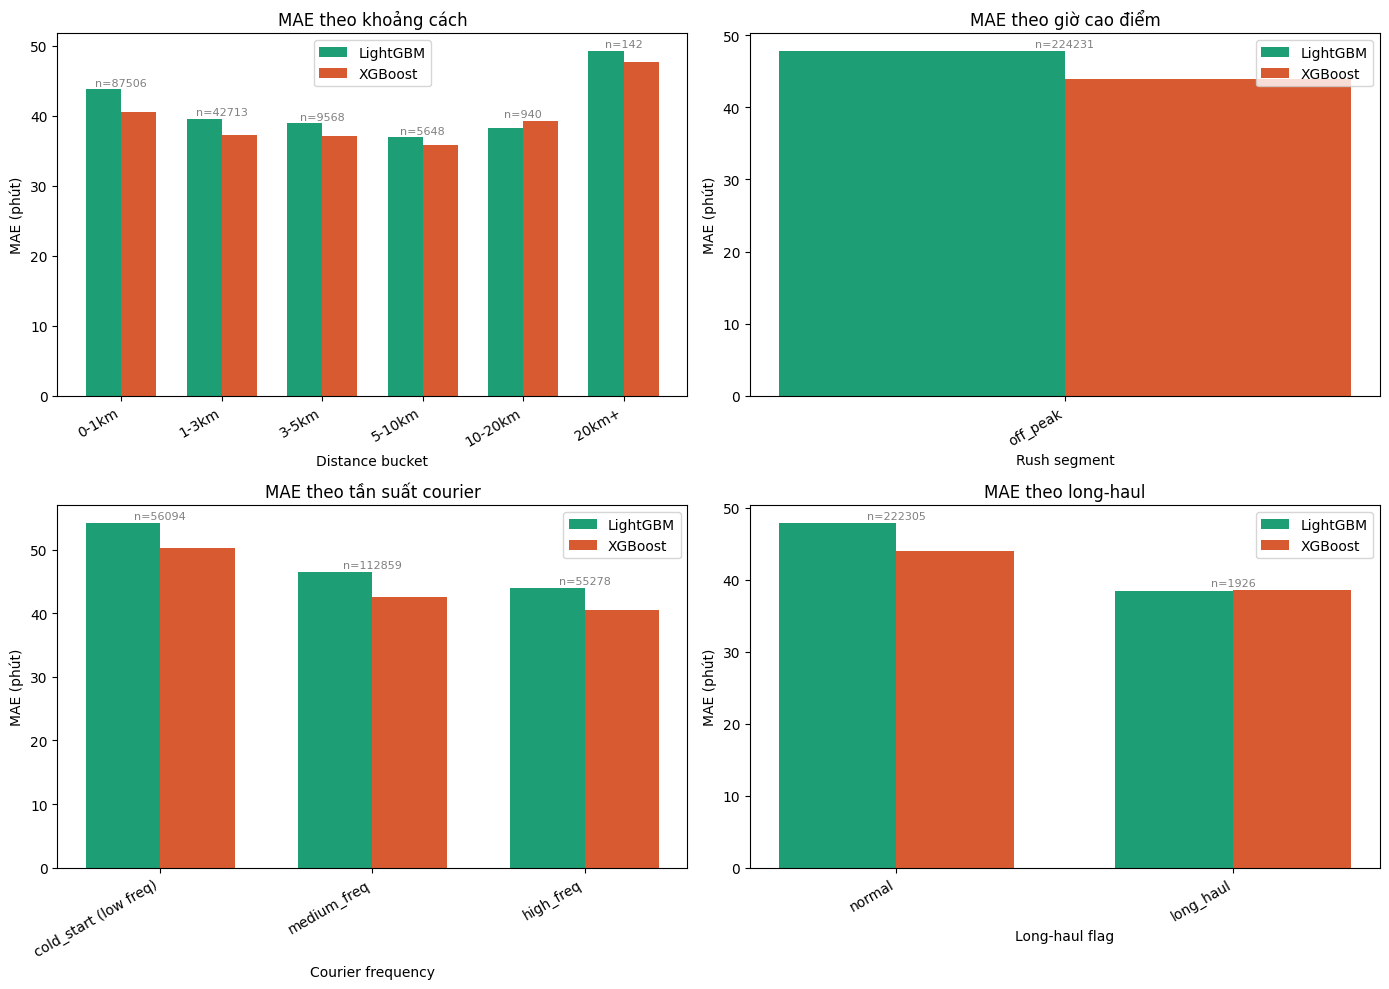

In [ ]:
# ====================== 7.9 VISUALIZE: MAE THEO TỪNG SEGMENT ======================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def plot_segment_mae(ax, seg_df, title, xlabel):
    x = np.arange(len(seg_df))
    width = 0.35
    ax.bar(x - width/2, seg_df['mae_lgb'], width, label='LightGBM', color='#1D9E75')
    ax.bar(x + width/2, seg_df['mae_xgb'], width, label='XGBoost', color='#D85A30')
    ax.set_xticks(x)
    ax.set_xticklabels(seg_df.index, rotation=30, ha='right')
    ax.set_ylabel('MAE (phút)')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend()
    # ghi số n sample lên mỗi cặp cột
    for i, n in enumerate(seg_df['n']):
        ax.text(i, max(seg_df['mae_lgb'].iloc[i], seg_df['mae_xgb'].iloc[i]) + 0.5,
                 f"n={n}", ha='center', fontsize=8, color='gray')

plot_segment_mae(axes[0, 0], seg_distance, "MAE theo khoảng cách", "Distance bucket")
plot_segment_mae(axes[0, 1], seg_rush, "MAE theo giờ cao điểm", "Rush segment")
plot_segment_mae(axes[1, 0], seg_courier, "MAE theo tần suất courier", "Courier frequency")
plot_segment_mae(axes[1, 1], seg_long_haul, "MAE theo long-haul", "Long-haul flag")

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/step7_segment_mae.png", dpi=150)
plt.show()

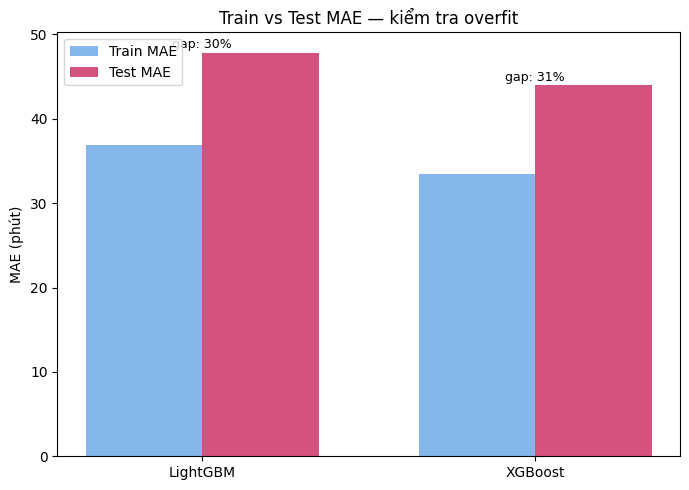

In [ ]:
# ====================== 7.10 VISUALIZE: TRAIN vs TEST GAP ======================
fig, ax = plt.subplots(figsize=(7, 5))

models = ['LightGBM', 'XGBoost']
train_maes = [mae_rmse(y_train_min, pred_lgb_train_min)[0], mae_rmse(y_train_min, pred_xgb_train_min)[0]]
test_maes  = [mae_rmse(y_test_min, pred_lgb_test_min)[0],  mae_rmse(y_test_min, pred_xgb_test_min)[0]]

x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, train_maes, width, label='Train MAE', color='#85B7EB')
ax.bar(x + width/2, test_maes, width, label='Test MAE', color='#D4537E')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('MAE (phút)')
ax.set_title('Train vs Test MAE — kiểm tra overfit')
ax.legend()

for i, (tr, te) in enumerate(zip(train_maes, test_maes)):
    gap_pct = (te - tr) / tr * 100
    ax.text(i, max(tr, te) + 0.5, f"gap: {gap_pct:.0f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/step7_train_test_gap.png", dpi=150)
plt.show()

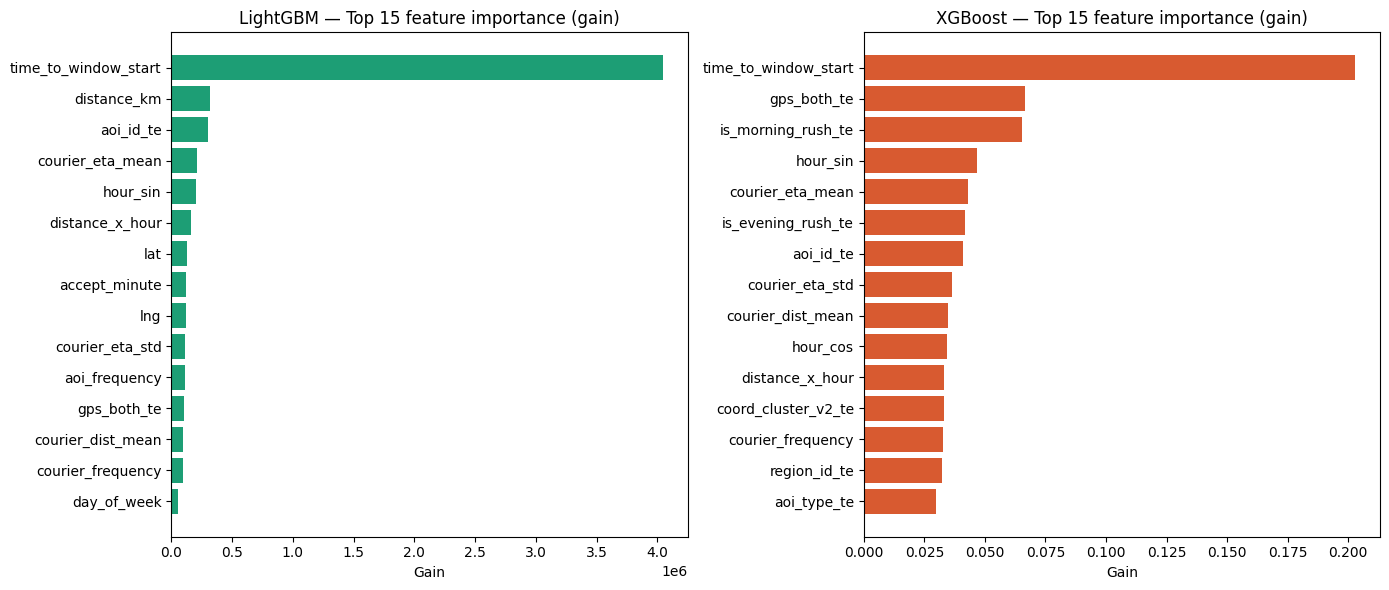

In [ ]:
# ====================== 7.11 VISUALIZE: FEATURE IMPORTANCE (TOP 15) ======================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_lgb = lgb_imp.head(15).sort_values('importance_gain')
axes[0].barh(top_lgb['feature'], top_lgb['importance_gain'], color='#1D9E75')
axes[0].set_title('LightGBM — Top 15 feature importance (gain)')
axes[0].set_xlabel('Gain')

top_xgb = xgb_imp.head(15).sort_values('importance_gain')
axes[1].barh(top_xgb['feature'], top_xgb['importance_gain'], color='#D85A30')
axes[1].set_title('XGBoost — Top 15 feature importance (gain)')
axes[1].set_xlabel('Gain')

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/step7_feature_importance.png", dpi=150)
plt.show()

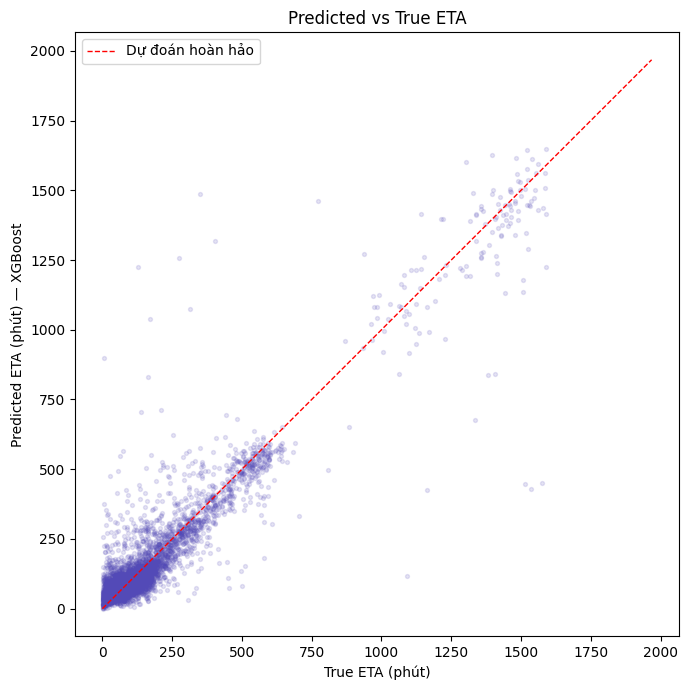

In [ ]:
# ====================== 7.12 VISUALIZE: SCATTER PRED vs TRUE (lỗi theo magnitude) ======================
fig, ax = plt.subplots(figsize=(7, 7))

sample_idx = np.random.choice(len(eval_df), size=min(5000, len(eval_df)), replace=False)
ax.scatter(eval_df['y_true_min'].values[sample_idx],
           eval_df['pred_xgb_min'].values[sample_idx],
           alpha=0.15, s=8, color='#534AB7')

max_val = max(eval_df['y_true_min'].max(), eval_df['pred_xgb_min'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Dự đoán hoàn hảo')
ax.set_xlabel('True ETA (phút)')
ax.set_ylabel('Predicted ETA (phút) — XGBoost')
ax.set_title('Predicted vs True ETA')
ax.legend()
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/step7_pred_vs_true.png", dpi=150)
plt.show()